# Minggu 1

## 4.1 A. Audit Kualitas Data

### 1. Baca CSV dengan timestamp sebagai tipe tanggal-waktu. Laporkan jumlah baris, jumlah kolom, periode pengamatan, jumlah kolam, dan interval pencatatan.

In [ ]:
import pandas as pd

df = pd.read_csv(
    "smart_aqua_synthetic_water_quality.csv",
    parse_dates=["timestamp"]
)

df = df.sort_values(
    ["pond_id","timestamp"]
).reset_index(drop=True)

print("Shape: ", df.shape)
print("Periode:", df["timestamp"].min(), "sampai", df["timestamp"].max())
print("Jumlah kolam:", df["pond_id"].nunique())
print("Kolam:", sorted(df["pond_id"].unique()))

Shape:  (23040, 26)
Periode: 2026-01-05 00:00:00 sampai 2026-03-05 23:30:00
Jumlah kolam: 8
Kolam: ['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'P08']


### 2. Periksa keunikan record_id dan kombinasi pond_id–timestamp. Periksa apakah urutan waktu setiap kolam lengkap dan konsisten.

In [ ]:
# cari keunikan record by record_id
print("Total record : ", len(df))
print("record_id unik : ", df["record_id"].unique())

# cari keunikan kombinasi pond_id + timestamp
pond_timestamp_unique = df[["pond_id","timestamp"]].drop_duplicates().shape[0]

print("Kombinasi pond_id + timestamp unik : ", pond_timestamp_unique)

# cek duplikasi
print("\n Duplikasi record_id : ", df["record_id"].duplicated().sum())
print("Duplikasi pond_id - timestamp : ", df.duplicated(["pond_id","timestamp"]).sum())

Total record :  8176
record_id unik :  ['AQUA-000001' 'AQUA-000002' 'AQUA-000003' ... 'AQUA-008174' 'AQUA-008175'
 'AQUA-008176']
Kombinasi pond_id + timestamp unik :  8176

 Duplikasi record_id :  0
Duplikasi pond_id - timestamp :  0


tidak ditemukan record_id yang duplikat dan kombinasi pond_id + timestamp yang duplikat

#### Cek kelengkapan interval waku

perlu dipastikan bahwa untuk setiap kolam, timestamp berjalan dengan normal (00:00 sampai 23.30). gaada tiba2 01:00 sampai 03:00

In [ ]:
for pond, group in df.groupby("pond_id"):
  ts = group["timestamp"].sort_values()

  interval = ts.diff().dropna()

  print(f"\n{pond}")
  print("Jumlah observasi : ", len(group))
  print("Awal : ", ts.min())
  print("Akhir : ", ts.max())
  print("Interval : " )
  print(interval.value_counts())


P01
Jumlah observasi :  2880
Awal :  2026-01-05 00:00:00
Akhir :  2026-03-05 23:30:00
Interval : 
timestamp
0 days 00:30:00    2879
Name: count, dtype: int64

P02
Jumlah observasi :  2880
Awal :  2026-01-05 00:00:00
Akhir :  2026-03-05 23:30:00
Interval : 
timestamp
0 days 00:30:00    2879
Name: count, dtype: int64

P03
Jumlah observasi :  2416
Awal :  2026-01-05 00:00:00
Akhir :  2026-02-24 07:30:00
Interval : 
timestamp
0 days 00:30:00    2415
Name: count, dtype: int64


Kesimpulan dari sini, Dataset terdiri atas 23.040 observasi dan 26 variabel yang merepresentasikan delapan kolan selama 60 hari pengamatan. Setiap kolam memiliki 2.88- observasi dengan interval pencatatan 30 menit. Pemeriksaan menunjukan bahwa seluruh record_id bersifat unik dan tidak ditemukan duplikasi pada kombinasi pond_id dan timestamp. Urutan waktu pada masing2 kolam juga konsisten dengan interval 30 menit tanpa ditemukan jeda pencatatan.

### 3. Buat tabel tipe data, jumlah nilai hilang, persentase nilai hilang, jumlah nilai unik, minimum, dan maksimum untuk setiap variabel.

In [ ]:
audit = pd.DataFrame({
    "variable" : df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing": df.isna().sum().values,
    "missing_pct":(df.isna().mean() * 100).values,
    "unique": df.nunique(dropna=True).values,
    "min": [
        df[c].min() if pd.api.types.is_numeric_dtype(df[c]) else None
        for c in df.columns
    ],
    "max": [
        df[c].max() if pd.api.types.is_numeric_dtype(df[c]) else None
        for c in df.columns
    ]
})

audit

,variable,dtype,missing,missing_pct,unique,min,max
0,record_id,object,0,0.000000,8176,NaN,NaN
1,timestamp,datetime64[ns],0,0.000000,2880,NaN,NaN
2,pond_id,object,0,0.000000,3,NaN,NaN
3,day_of_cycle,int64,0,0.000000,60,1.000,60.000
4,hour_decimal,float64,0,0.000000,48,0.000,23.500
5,time_period,object,0,0.000000,4,NaN,NaN
6,species,object,0,0.000000,1,NaN,NaN
7,pond_volume_m3,int64,0,0.000000,3,48.000,52.000
8,stocking_density_kg_m3,float64,0,0.000000,154,15.770,34.350
9,biomass_kg,float64,0,0.000000,172,16.000,1649.000


ben penak diwaca

In [ ]:
audit["missing_pct"] = audit["missing_pct"].round(2)

audit

,variable,dtype,missing,missing_pct,unique,min,max
0,record_id,object,0,0.00,8176,NaN,NaN
1,timestamp,datetime64[ns],0,0.00,2880,NaN,NaN
2,pond_id,object,0,0.00,3,NaN,NaN
3,day_of_cycle,int64,0,0.00,60,1.000,60.000
4,hour_decimal,float64,0,0.00,48,0.000,23.500
5,time_period,object,0,0.00,4,NaN,NaN
6,species,object,0,0.00,1,NaN,NaN
7,pond_volume_m3,int64,0,0.00,3,48.000,52.000
8,stocking_density_kg_m3,float64,0,0.00,154,15.770,34.350
9,biomass_kg,float64,0,0.00,172,16.000,1649.000


### 4. Ringkas frekuensi setiap nilai sensor_quality_flag. Temukan contoh spike, flatline, drift, dan missing value pada grafik waktu.

In [ ]:
flag_summary = (
    df["sensor_quality_flag"]
    .value_counts()
    .rename_axis("sensor_quality_flag")
    .reset_index(name="count")
)

flag_summary["percentage"] = (
    flag_summary["count"] / len(df) * 100
).round(2)

flag_summary

,sensor_quality_flag,count,percentage
0,OK,7949,97.22
1,PH_DRIFT,95,1.16
2,DO_FLATLINE,57,0.70
3,SENSOR_MISSING,56,0.68
4,DO_SPIKE,17,0.21
5,MULTIPLE,1,0.01


Mencari misssing value


In [ ]:
sensor_cols = [
    "temperature_c",
    "ph",
    "dissolved_oxygen_mg_l",
    "ammonia_mg_l",
    "nitrite_mg_l",
    "turbidity_ntu"
]

missing_by_flag = pd.crosstab(
    df["sensor_quality_flag"],
    df[sensor_cols].isna().any(axis=1)
)

missing_by_flag

col_0,False,True
sensor_quality_flag,,
DO_FLATLINE,57,0
DO_SPIKE,17,0
MULTIPLE,0,1
OK,7949,0
PH_DRIFT,95,0
SENSOR_MISSING,0,56


Nilai spike

In [ ]:
df.loc[
    df["sensor_quality_flag"] == "DO_SPIKE",
    [
        "timestamp",
        "pond_id",
        "dissolved_oxygen_mg_l",
        "sensor_quality_flag"
    ]
].head(10)

,timestamp,pond_id,dissolved_oxygen_mg_l,sensor_quality_flag
1255,2026-01-31 03:30:00,P01,-0.93,DO_SPIKE
1744,2026-02-10 08:00:00,P01,12.69,DO_SPIKE
1921,2026-02-14 00:30:00,P01,13.85,DO_SPIKE
2049,2026-02-16 16:30:00,P01,-0.73,DO_SPIKE
2187,2026-02-19 13:30:00,P01,-0.67,DO_SPIKE
2345,2026-02-22 20:30:00,P01,11.71,DO_SPIKE
2371,2026-02-23 09:30:00,P01,-0.25,DO_SPIKE
3199,2026-01-11 15:30:00,P02,13.22,DO_SPIKE
3733,2026-01-22 18:30:00,P02,12.59,DO_SPIKE
4965,2026-02-17 10:30:00,P02,-0.87,DO_SPIKE


Flatline

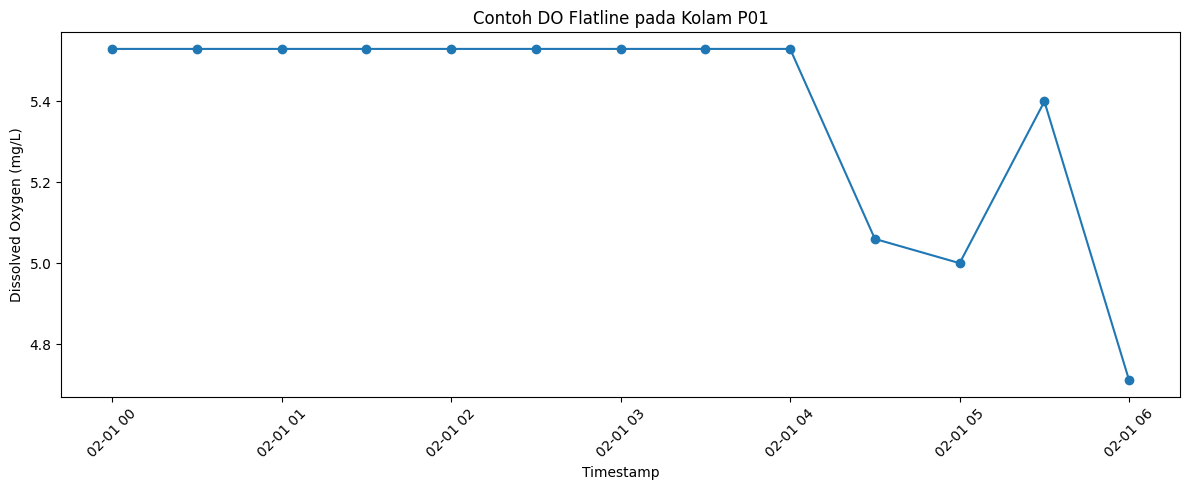

In [ ]:
pond = "P01"

plot_df = df[
    (df["pond_id"] == pond) &
    (df["timestamp"].between(
        "2026-02-01 00:00",
        "2026-02-01 06:00"
    ))
]

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    plot_df["timestamp"],
    plot_df["dissolved_oxygen_mg_l"],
    marker="o"
)

plt.xlabel("Timestamp")
plt.ylabel("Dissolved Oxygen (mg/L)")
plt.title("Contoh DO Flatline pada Kolam P01")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

drift

In [ ]:
ph_drift = df[df["sensor_quality_flag"] == "PH_DRIFT"]

ph_drift.groupby("pond_id").size()

,0
pond_id,
P01,42
P02,53


## B. Descriptive Analytics: Apa yang Terjadi?

### 1. Hitung mean, median, simpangan baku, minimum, maksimum, kuartil, IQR, dan koefisien variasi untuk seluruh parameter kualitas air. Jelaskan mengapa koefisien variasi tidak selalu tepat ketika mean mendekati nol.

In [ ]:
water_quality = [
    "temperature_c",
    "ph",
    "dissolved_oxygen_mg_l",
    "ammonia_mg_l",
    "nitrite_mg_l",
    "turbidity_ntu"
]

descriptive_stats = []

for col in water_quality:
    s = df[col].dropna()

    mean = s.mean()
    std = s.std()

    descriptive_stats.append({
        "Parameter": col,
        "Mean": mean,
        "Median": s.median(),
        "Std": std,
        "Min": s.min(),
        "Q1": s.quantile(0.25),
        "Q3": s.quantile(0.75),
        "Max": s.max(),
        "IQR": s.quantile(0.75) - s.quantile(0.25),
        "CV (%)": (std / mean * 100) if mean != 0 else np.nan
    })

descriptive_stats = pd.DataFrame(descriptive_stats)

descriptive_stats.round(3)

,Parameter,Mean,Median,Std,Min,Q1,Q3,Max,IQR,CV (%)
0,temperature_c,28.407,28.410,1.226,25.840,27.340,29.480,31.230,2.140,4.317
1,ph,7.352,7.340,0.161,7.020,7.220,7.480,8.330,0.260,2.185
2,dissolved_oxygen_mg_l,5.302,5.270,0.724,-0.980,4.820,5.770,15.500,0.950,13.650
3,ammonia_mg_l,0.307,0.309,0.078,0.115,0.248,0.364,0.529,0.116,25.316
4,nitrite_mg_l,0.253,0.248,0.068,0.103,0.199,0.303,0.452,0.104,27.033
5,turbidity_ntu,47.044,46.700,7.061,26.100,41.800,51.900,70.500,10.100,15.009


### 2. Bandingkan statistik kualitas air menurut:
- kolam;
- time_period;
- jam pengamatan; dan
- fase awal, tengah, dan akhir siklus budidaya.

In [ ]:
pond_quality = (
    df.groupby("pond_id")[water_quality]
    .mean()
    .round(3)
)

pond_quality

,temperature_c,ph,dissolved_oxygen_mg_l,ammonia_mg_l,nitrite_mg_l,turbidity_ntu
pond_id,,,,,,
P01,28.138,7.353,5.447,0.248,0.202,42.065
P02,28.439,7.356,5.310,0.315,0.258,47.387
P03,28.690,7.345,5.121,0.369,0.308,52.560


Kolam

<Figure size 1200x600 with 0 Axes>

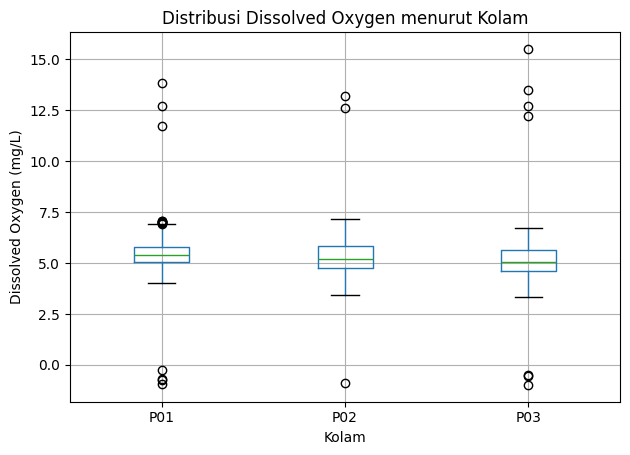

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

df.boxplot(
    column="dissolved_oxygen_mg_l",
    by="pond_id"
)

plt.title("Distribusi Dissolved Oxygen menurut Kolam")
plt.suptitle("")
plt.xlabel("Kolam")
plt.ylabel("Dissolved Oxygen (mg/L)")
plt.tight_layout()
plt.show()

time period

In [ ]:
period_quality = (
    df.groupby("time_period")[water_quality]
    .mean()
    .round(3)
)

period_quality

,temperature_c,ph,dissolved_oxygen_mg_l,ammonia_mg_l,nitrite_mg_l,turbidity_ntu
time_period,,,,,,
afternoon,29.870,7.529,6.024,0.306,0.251,47.174
dawn,26.953,7.176,4.778,0.306,0.254,45.316
morning,28.332,7.348,5.001,0.302,0.253,47.815
night,28.482,7.355,5.408,0.316,0.254,47.880


jam pengamatan (rata2 perjam)

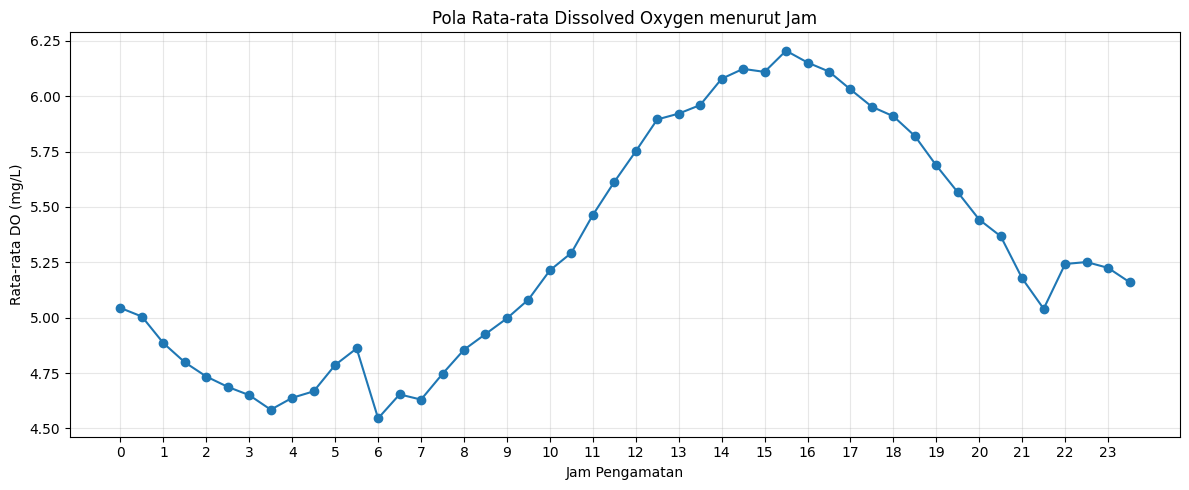

In [ ]:
hourly_mean = (
    df.groupby("hour_decimal")[water_quality]
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_mean.index,
    hourly_mean["dissolved_oxygen_mg_l"],
    marker="o"
)

plt.xlabel("Jam Pengamatan")
plt.ylabel("Rata-rata DO (mg/L)")
plt.title("Pola Rata-rata Dissolved Oxygen menurut Jam")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fase awal, tengah, dan akhir siklus budidaya.

In [ ]:
def cycle_phase(day):
    if day <= 20:
        return "Awal"
    elif day <= 40:
        return "Tengah"
    else:
        return "Akhir"

df["cycle_phase"] = df["day_of_cycle"].apply(cycle_phase)

phase_quality = (
    df.groupby("cycle_phase")[water_quality]
    .mean()
    .reindex(["Awal", "Tengah", "Akhir"])
    .round(3)
)

phase_quality

,temperature_c,ph,dissolved_oxygen_mg_l,ammonia_mg_l,nitrite_mg_l,turbidity_ntu
cycle_phase,,,,,,
Awal,28.585,7.355,5.395,0.254,0.206,42.191
Tengah,28.432,7.355,5.270,0.316,0.258,47.698
Akhir,28.166,7.344,5.231,0.361,0.304,52.064


### 4. Hitung frekuensi kondisi berisiko pada waktu pengamatan menggunakan ambang DO, amonia, dan nitrit yang diberikan. Sajikan proporsi menurut kolam dan jam.

- DO < 3,5 mg/L
- ammonia > 0,55 mg/L
- nitrite > 0,35 mg/L

In [ ]:
df["risk_condition"] = (
    (df["dissolved_oxygen_mg_l"] < 3.5) |
    (df["ammonia_mg_l"] > 0.55) |
    (df["nitrite_mg_l"] > 0.35)
)

df["risk_condition"].value_counts()

,count
risk_condition,
False,7328
True,848


In [ ]:
risk_summary = (
    df["risk_condition"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percentage")
)

risk_summary

,percentage
risk_condition,
False,89.62818
True,10.37182


Resiko menurut kolam

In [ ]:
risk_by_pond = (
    df.groupby("pond_id")["risk_condition"]
    .agg(
        risk_count="sum",
        risk_rate="mean"
    )
)

risk_by_pond["risk_pct"] = risk_by_pond["risk_rate"] * 100

risk_by_pond[
    ["risk_count", "risk_pct"]
].round(3)

,risk_count,risk_pct
pond_id,,
P01,4,0.139
P02,172,5.972
P03,672,27.815


Resiko menurut jam

In [ ]:
risk_by_hour = (
    df.groupby("hour_decimal")["risk_condition"]
    .mean()
    .mul(100)
)

risk_by_hour.round(2)

,risk_condition
hour_decimal,
0.0,10.53
0.5,11.70
1.0,10.53
1.5,11.11
2.0,8.77
2.5,9.94
3.0,11.11
3.5,12.87
4.0,11.70


visualisasi kolam x jam

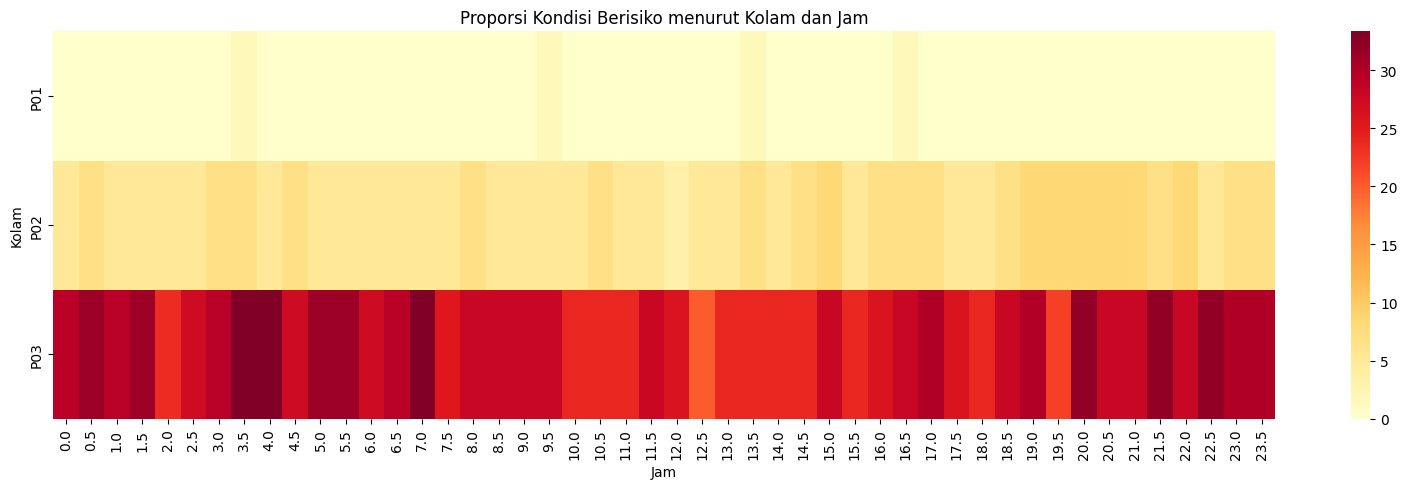

In [ ]:
import seaborn as sns

risk_heatmap = (
    df.groupby(["pond_id", "hour_decimal"])["risk_condition"]
    .mean()
    .unstack()
    * 100
)

plt.figure(figsize=(16, 5))

sns.heatmap(
    risk_heatmap,
    annot=False,
    cmap="YlOrRd"
)

plt.title("Proporsi Kondisi Berisiko menurut Kolam dan Jam")
plt.xlabel("Jam")
plt.ylabel("Kolam")
plt.tight_layout()
plt.show()

fish stress event

In [ ]:
stress_summary = (
    df["fish_stress_event"]
    .value_counts()
    .sort_index()
)

stress_summary

,count
fish_stress_event,
0.0,8155
1.0,20


Stress menurut kolam

In [ ]:
stress_by_pond = (
    df.groupby("pond_id")["fish_stress_event"]
    .agg(
        stress_count="sum",
        stress_rate="mean"
    )
)

stress_by_pond["stress_pct"] = stress_by_pond["stress_rate"] * 100

stress_by_pond[
    ["stress_count", "stress_pct"]
].round(3)

,stress_count,stress_pct
pond_id,,
P01,8.0,0.278
P02,3.0,0.104
P03,9.0,0.373


stress menurut jam

In [ ]:
stress_by_hour = (
    df.groupby("hour_decimal")["fish_stress_event"]
    .mean()
    .mul(100)
)

stress_by_hour.round(3)

,fish_stress_event
hour_decimal,
0.0,0.000
0.5,0.000
1.0,0.000
1.5,0.000
2.0,0.000
2.5,0.000
3.0,0.000
3.5,0.000
4.0,0.000


jam dengan event terbanyak

In [ ]:
stress_by_hour.sort_values(ascending=False).head(10)

,fish_stress_event
hour_decimal,
8.0,1.176471
7.5,0.588235
18.5,0.588235
17.5,0.588235
22.0,0.588235
23.5,0.588235
21.0,0.588235
21.5,0.588235
12.0,0.588235


grafik distribusi

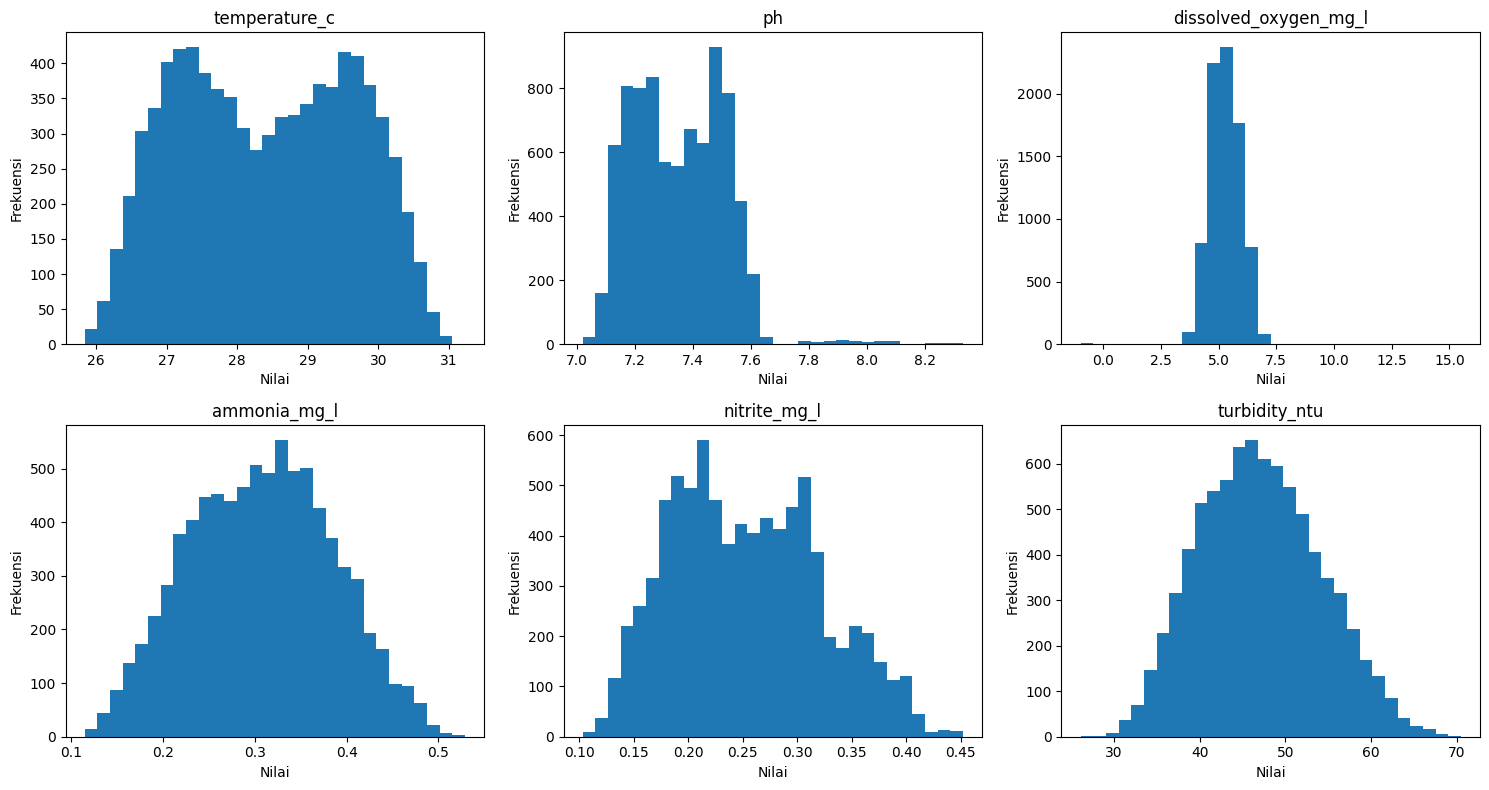

In [ ]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 8)
)

for ax, col in zip(axes.flat, water_quality):

    ax.hist(
        df[col].dropna(),
        bins=30
    )

    ax.set_title(col)
    ax.set_xlabel("Nilai")
    ax.set_ylabel("Frekuensi")

plt.tight_layout()
plt.show()

Grafik waktu normal dengan waktu terbanyak

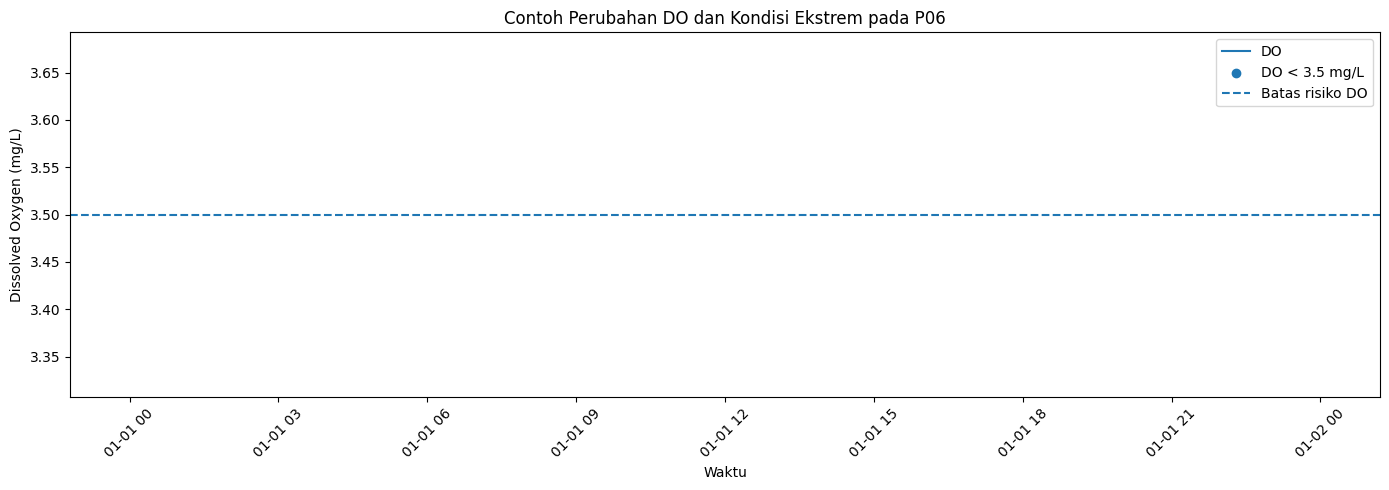

In [ ]:
sample = df[
    (df["pond_id"] == "P06") &
    (df["timestamp"].between(
        "2026-02-01",
        "2026-02-03"
    ))
].copy()

plt.figure(figsize=(14, 5))

plt.plot(
    sample["timestamp"],
    sample["dissolved_oxygen_mg_l"],
    label="DO"
)

risk_sample = sample[
    sample["dissolved_oxygen_mg_l"] < 3.5
]

plt.scatter(
    risk_sample["timestamp"],
    risk_sample["dissolved_oxygen_mg_l"],
    label="DO < 3.5 mg/L"
)

plt.axhline(
    3.5,
    linestyle="--",
    label="Batas risiko DO"
)

plt.xlabel("Waktu")
plt.ylabel("Dissolved Oxygen (mg/L)")
plt.title("Contoh Perubahan DO dan Kondisi Ekstrem pada P06")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##**4.3 C. Diagnotic Analytics: Mengapa Terjadi**

1. Risiko antar-kolam

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

In [ ]:
# Ringkasan risiko tiap kolam

risk_by_pond = (
    df.groupby("pond_id")
    .agg(
        total_observation=("record_id","count"),
        risk_count=("risk_next_3h","sum"),
        risk_rate=("risk_next_3h","mean"),
        avg_biomass=("biomass_kg","mean"),
        avg_density=("stocking_density_kg_m3","mean"),
        avg_temperature=("temperature_c","mean")
    )
    .reset_index()
)

risk_by_pond["risk_rate"] = risk_by_pond["risk_rate"]*100

risk_by_pond

,pond_id,total_observation,risk_count,risk_rate,avg_biomass,avg_density,avg_temperature
0,P01,2880,0.0,0.000000,1063.911667,20.460000,28.138038
1,P02,2880,192.0,6.680585,1206.636667,24.132833,28.439292
2,P03,2880,1172.0,40.779402,1401.256667,29.193000,28.639042
3,P04,2880,666.0,23.173278,1284.486667,25.689500,28.540778
4,P05,2880,431.0,14.996521,1141.763333,25.372833,29.139476
5,P06,2880,1656.0,57.620042,1453.160000,30.918833,28.737726
6,P07,2880,34.0,1.183020,1167.710000,21.623833,28.335740
7,P08,2880,1003.0,34.899095,1323.411667,27.008333,28.839868


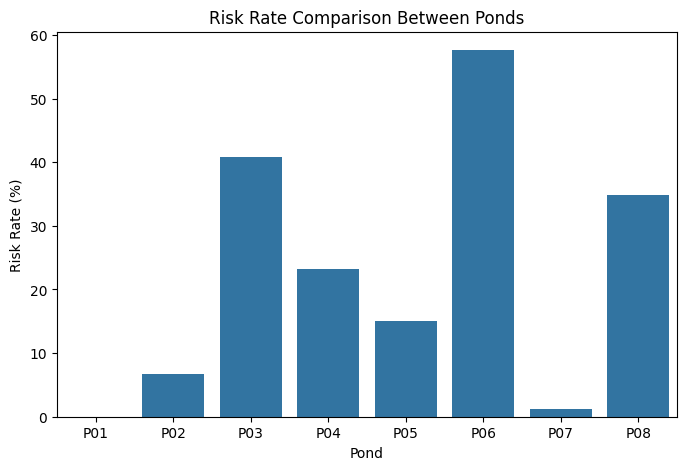

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=risk_by_pond,
    x="pond_id",
    y="risk_rate"
)

plt.ylabel("Risk Rate (%)")
plt.xlabel("Pond")
plt.title("Risk Rate Comparison Between Ponds")

plt.show()

2. Aerator dan Oksigen Terlarut

In [ ]:
df.groupby("aerator_status")[
    "dissolved_oxygen_mg_l"
].agg(
    ["count","mean","median","std"]
)

,count,mean,median,std
aerator_status,,,,
OFF,7878,5.471550,5.49,0.800607
ON,15124,5.067277,4.97,0.896556


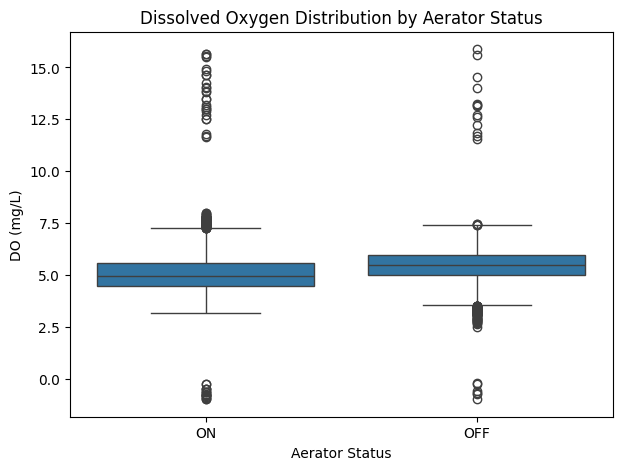

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="aerator_status",
    y="dissolved_oxygen_mg_l"
)

plt.title("Dissolved Oxygen Distribution by Aerator Status")
plt.xlabel("Aerator Status")
plt.ylabel("DO (mg/L)")

plt.show()

Stratifikasi berdasarkan kolam

In [ ]:
do_aerator_pond = (
    df.groupby(
        ["pond_id","aerator_status"]
    )
    ["dissolved_oxygen_mg_l"]
    .mean()
    .reset_index()
)

do_aerator_pond

,pond_id,aerator_status,dissolved_oxygen_mg_l
0,P01,OFF,5.523180
1,P01,ON,5.331383
2,P02,OFF,5.442270
3,P02,ON,5.221727
4,P03,OFF,5.031204
5,P03,ON,5.045661
6,P04,OFF,5.255641
7,P04,ON,5.096336
8,P05,OFF,5.498846
9,P05,ON,5.088198


3. Gangguan aerator

In [ ]:
do_aerator_pond = (
    df.groupby(
        ["pond_id","aerator_status"]
    )
    ["dissolved_oxygen_mg_l"]
    .mean()
    .reset_index()
)

do_aerator_pond

,pond_id,aerator_status,dissolved_oxygen_mg_l
0,P01,OFF,5.523180
1,P01,ON,5.331383
2,P02,OFF,5.442270
3,P02,ON,5.221727
4,P03,OFF,5.031204
5,P03,ON,5.045661
6,P04,OFF,5.255641
7,P04,ON,5.096336
8,P05,OFF,5.498846
9,P05,ON,5.088198


Analisis Gangguan Aerator

In [ ]:
df = df.sort_values(
    ["pond_id","timestamp"]
)


df["aerator_fault_event"] = (
    df["aerator_fault"]
    != df["aerator_fault"].shift(1)
)


fault_time = df[
    df["aerator_fault_event"]
][
    [
        "pond_id",
        "timestamp"
    ]
]


fault_time.head()

,pond_id,timestamp
0,P01,2026-01-05 00:00:00
341,P01,2026-01-12 02:30:00
342,P01,2026-01-12 03:00:00
482,P01,2026-01-15 01:00:00
483,P01,2026-01-15 01:30:00


In [ ]:
fault_effect=[]


for _,row in fault_time.iterrows():

    pond=row["pond_id"]
    time=row["timestamp"]

    temp=df[
        (df.pond_id==pond)
        &
        (df.timestamp.between(
            time-pd.Timedelta(hours=3),
            time+pd.Timedelta(hours=3)
        ))
    ].copy()

    temp["relative_hour"] = (
        (temp.timestamp-time)
        /
        pd.Timedelta(hours=1)
    )

    fault_effect.append(temp)


fault_analysis = pd.concat(
    fault_effect,
    ignore_index=True
)

fault_analysis.head()

,record_id,timestamp,pond_id,day_of_cycle,hour_decimal,time_period,species,pond_volume_m3,stocking_density_kg_m3,biomass_kg,...,aerator_status,aerator_fault,rainfall_mm,water_exchange_pct,sensor_quality_flag,fish_stress_event,risk_next_3h,dataset_split,aerator_fault_event,relative_hour
0,AQUA-000001,2026-01-05 00:00:00,P01,1,0.0,dawn,Nila,52,15.77,820.0,...,ON,0,0.0,0,OK,0,0.0,TRAIN,True,0.0
1,AQUA-000002,2026-01-05 00:30:00,P01,1,0.5,dawn,Nila,52,15.77,820.0,...,ON,0,0.0,0,OK,0,0.0,TRAIN,False,0.5
2,AQUA-000003,2026-01-05 01:00:00,P01,1,1.0,dawn,Nila,52,15.77,820.0,...,ON,0,0.0,0,OK,0,0.0,TRAIN,False,1.0
3,AQUA-000004,2026-01-05 01:30:00,P01,1,1.5,dawn,Nila,52,15.77,820.0,...,ON,0,0.0,0,SENSOR_MISSING,0,0.0,TRAIN,False,1.5
4,AQUA-000005,2026-01-05 02:00:00,P01,1,2.0,dawn,Nila,52,15.77,820.0,...,ON,0,0.0,0,OK,0,0.0,TRAIN,False,2.0


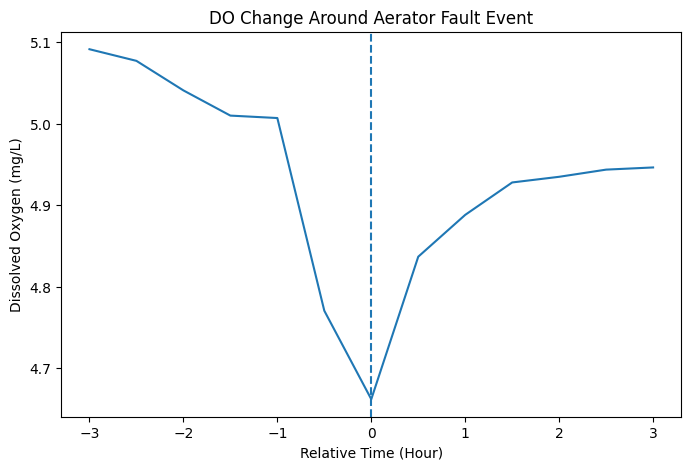

In [ ]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=fault_analysis,
    x="relative_hour",
    y="dissolved_oxygen_mg_l",
    errorbar=None
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "DO Change Around Aerator Fault Event"
)

plt.xlabel(
    "Relative Time (Hour)"
)

plt.ylabel(
    "Dissolved Oxygen (mg/L)"
)

plt.show()

4. Efek Tertunda pakan

In [ ]:
df=df.sort_values(
    ["pond_id","timestamp"]
)


for i in range(1,13):

    df[f"feed_lag_{i}"] = (
        df.groupby("pond_id")
        ["feed_kg"]
        .shift(i)
    )

In [ ]:
lag_result=[]


for i in range(1,13):

    lag_result.append(
        {
            "lag":i,
            "ammonia_corr":
            df[f"feed_lag_{i}"].corr(
                df["ammonia_mg_l"]
            ),

            "nitrite_corr":
            df[f"feed_lag_{i}"].corr(
                df["nitrite_mg_l"]
            ),

            "DO_corr":
            df[f"feed_lag_{i}"].corr(
                df["dissolved_oxygen_mg_l"]
            )
        }
    )


lag_result=pd.DataFrame(lag_result)

lag_result

In [ ]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=lag_result,
    x="lag",
    y="ammonia_corr",
    marker="o"
)

plt.title(
    "Feed Lag Effect on Ammonia"
)

plt.xlabel(
    "Lag Interval (30 minutes)"
)

plt.ylabel(
    "Correlation"
)

plt.show()

5. Hujan

In [ ]:
#Kategori Hujan
df["rain_category"] = pd.cut(
    df["rainfall_mm"],
    bins=[
        -1,
        0,
        10,
        np.inf
    ],
    labels=[
        "No Rain",
        "Light Rain",
        "Heavy Rain"
    ]
)

In [ ]:
rain_analysis = (
    df.groupby("rain_category")
    [
        [
            "dissolved_oxygen_mg_l",
            "ammonia_mg_l",
            "nitrite_mg_l"
        ]
    ]
    .mean()
)

rain_analysis

6. Pertukaran air

In [ ]:
df["water_exchange_event"] = (
    df["water_exchange_pct"]>0
)


water_exchange_result = (
    df.groupby(
        "water_exchange_event"
    )
    [
        [
            "ammonia_mg_l",
            "nitrite_mg_l"
        ]
    ]
    .mean()pip install opencv-python

)


water_exchange_result